In [43]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
df = pd.read_csv("/content/Crop_recommendation.csv")

In [9]:
print(len(df))

2200


In [10]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [14]:
df.columns.tolist()

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

In [15]:
df['label'].nunique()

22

In [16]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [17]:
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
TARGET = ['label']

In [18]:
X = df[FEATURES].values
y = df[TARGET].values

In [20]:
le = LabelEncoder()
y_encode = le.fit_transform(y)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [21]:
le.classes_.tolist()

['apple',
 'banana',
 'blackgram',
 'chickpea',
 'coconut',
 'coffee',
 'cotton',
 'grapes',
 'jute',
 'kidneybeans',
 'lentil',
 'maize',
 'mango',
 'mothbeans',
 'mungbean',
 'muskmelon',
 'orange',
 'papaya',
 'pigeonpeas',
 'pomegranate',
 'rice',
 'watermelon']

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y_encode, test_size = 0.2, random_state = 42, stratify=y_encode)

In [26]:
x_train.shape

(1760, 7)

In [27]:
x_test.shape

(440, 7)

In [28]:
y_train.shape

(1760,)

In [29]:
y_test.shape

(440,)

In [31]:
model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = None,
    random_state = 42,
    n_jobs = -1,
)

In [32]:
model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [36]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

In [40]:
print(f"\n Test Accuracy: {accuracy * 100:.2f}%")
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


 Test Accuracy: 99.55%

 Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.0

In [41]:
cv_scores = cross_val_score(model, X_scaled, y_encode, cv=5)
print(f"\n 5-Fold Cross Val Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")



 5-Fold Cross Val Accuracy: 99.45% ± 0.23%


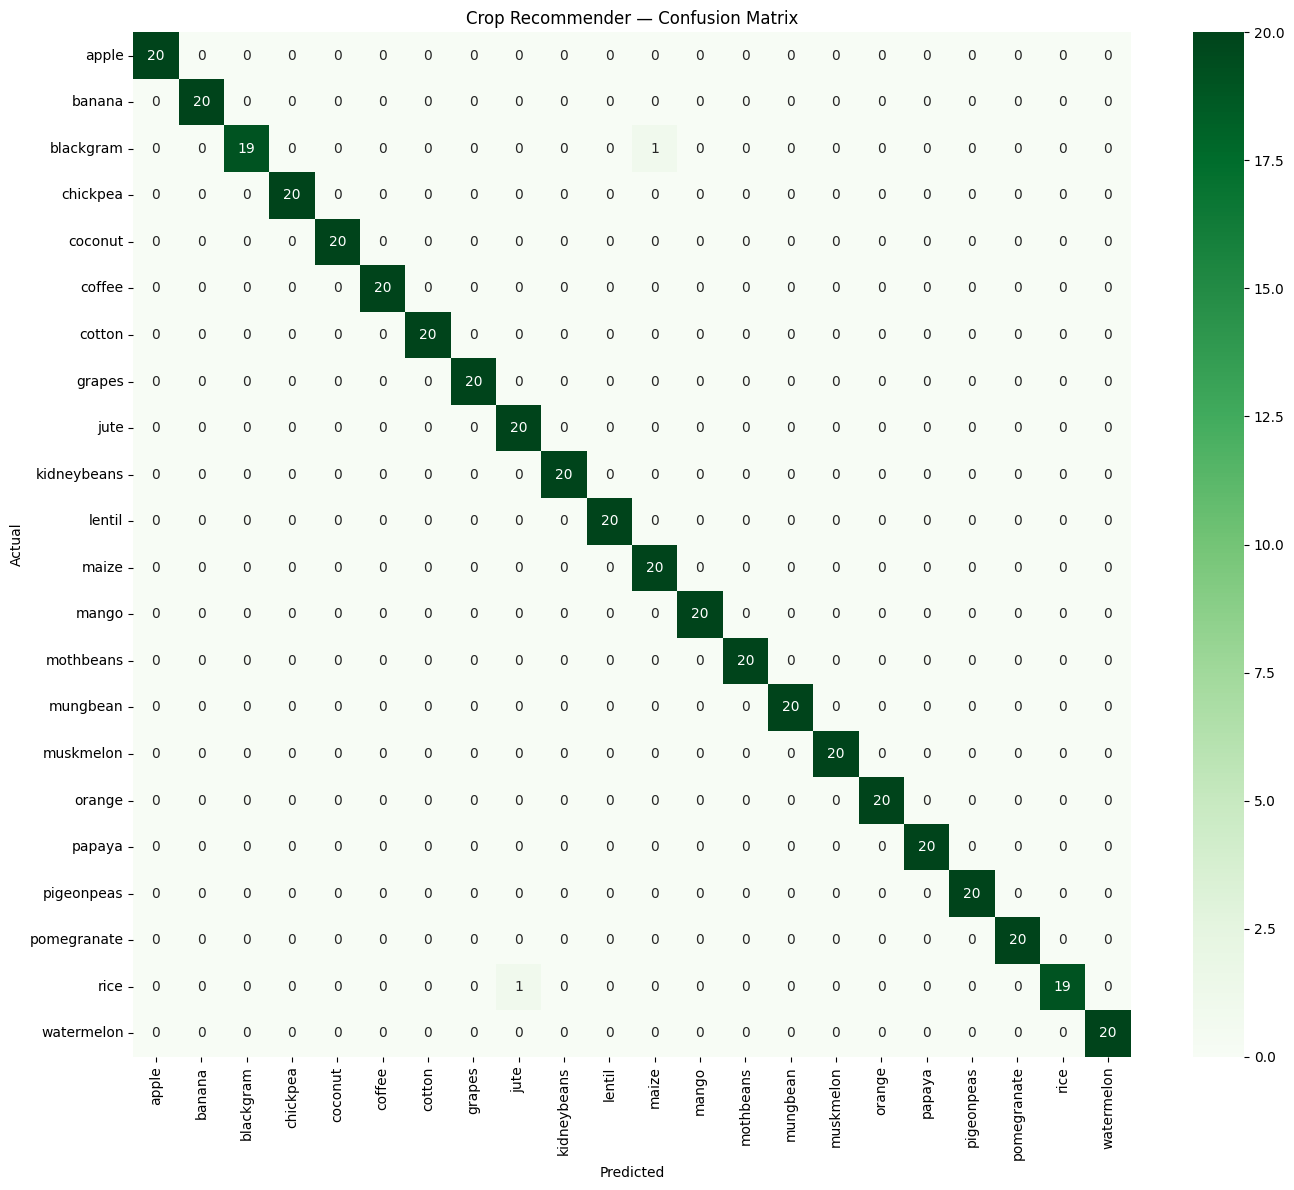

In [44]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Crop Recommender — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

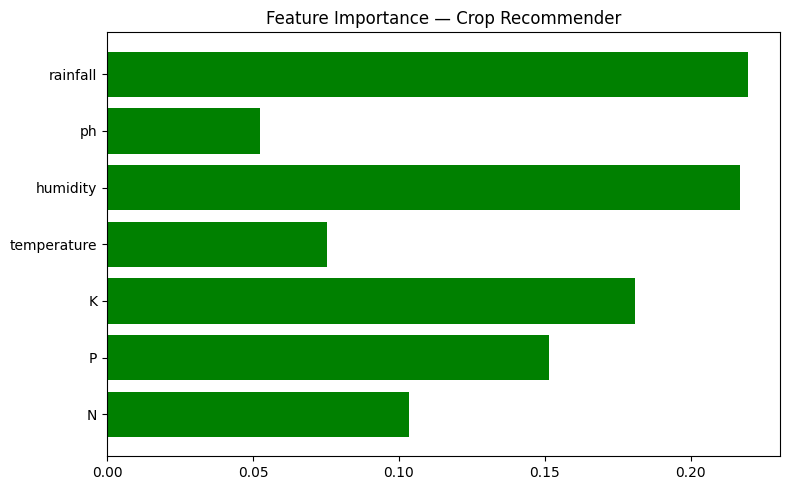

In [45]:
importances = model.feature_importances_
plt.figure(figsize=(8, 5))
plt.barh(FEATURES, importances, color="green")
plt.title("Feature Importance — Crop Recommender")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [46]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("model_info.json", "w") as f:
    json.dump({
        "features":  FEATURES,
        "crops":     le.classes_.tolist(),
        "accuracy":  round(accuracy, 4),
        "cv_mean":   round(cv_scores.mean(), 4),
    }, f, indent=2)

print("\n Saved: model.pkl, label_encoder.pkl, scaler.pkl, model_info.json")
print("   Download all 4 and place in backend/ml_models/crop_recommender/")



 Saved: model.pkl, label_encoder.pkl, scaler.pkl, model_info.json
   Download all 4 and place in backend/ml_models/crop_recommender/
